In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import os
import json as _json
import matplotlib.pyplot as plt
from IPython.display import display, HTML

notebook_dir = Path().resolve()
sys.path.insert(0, str(notebook_dir.parents[1] / "src"))

from config import PROF_DIR
from plot_style_utils import (
    apply_plot_theme,
    plot_ratio_distribution,
    plot_annotated_bar,
    display_summary_table,
    PALETTE,
)

# =========================
# USER SETTINGS
# =========================
DATA_DIR = PROF_DIR

MIN_YEAR = 2005
MAX_YEAR = 2024

# Revenue filter
MIN_REVENUE = 1.0

# Flagging thresholds for cost_ratio = (COGS + XSGA_COMPONENTS) / REVT
LOW_THRESHOLD = 0.40
HIGH_THRESHOLD = 1.20

# Extreme thresholds
EXTREME_LOW_THRESHOLD = 0.15
EXTREME_HIGH_THRESHOLD = 2.00

# Plot settings
TOP_N_EXCHANGES = 15
TOP_N_SECTORS = 15

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Data folder not found: {DATA_DIR.resolve()}")

apply_plot_theme()

print("Using data from:", DATA_DIR.resolve())


config.py loaded from: /Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/src/config.py
ROOT: /Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty
Using data from: /Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/data/processed/prof_components_extracted


In [2]:
rows = []
bad_files = []

for fp in sorted(DATA_DIR.glob("*.csv")):
    try:
        df = pd.read_csv(fp)
    except Exception as e:
        bad_files.append((fp.name, f"read_error: {e}"))
        continue

    if "Year" not in df.columns:
        bad_files.append((fp.name, "missing Year"))
        continue

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df = df.dropna(subset=["Year"]).copy()
    df["Year"] = df["Year"].astype(int)
    df = df[(df["Year"] >= MIN_YEAR) & (df["Year"] <= MAX_YEAR)].copy()

    if df.empty:
        continue

    if "Ticker" not in df.columns:
        df["Ticker"] = fp.stem
    if "firm" not in df.columns:
        df["firm"] = fp.stem

    rows.append(df)

if not rows:
    raise ValueError("No valid CSV files were loaded.")

panel = pd.concat(rows, ignore_index=True)

print(f"Loaded rows: {len(panel):,}")
print(f"Unique tickers: {panel['Ticker'].nunique():,}")

if bad_files:
    print("\nSkipped files:")
    for name, reason in bad_files[:20]:
        print(f"- {name}: {reason}")


Loaded rows: 9,773
Unique tickers: 635


In [3]:
required_cols = ["REVT", "COGS", "XSGA_COMPONENTS"]
missing_required = [c for c in required_cols if c not in panel.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

for col in required_cols:
    panel[col] = pd.to_numeric(panel[col], errors="coerce")

panel["COGS_filled"] = panel["COGS"].fillna(0.0)
panel["XSGA_filled"] = panel["XSGA_COMPONENTS"].fillna(0.0)

panel["REVT_valid"] = panel["REVT"].notna() & (panel["REVT"] > MIN_REVENUE)
panel["TOTAL_COST_PROXY"] = panel["COGS_filled"] + panel["XSGA_filled"]

panel["cost_ratio"] = np.where(
    panel["REVT_valid"],
    panel["TOTAL_COST_PROXY"] / panel["REVT"],
    np.nan
)

# Flag columns
panel["flag_low"]          = panel["cost_ratio"] < LOW_THRESHOLD
panel["flag_high"]         = panel["cost_ratio"] > HIGH_THRESHOLD
panel["flag_extreme_low"]  = panel["cost_ratio"] < EXTREME_LOW_THRESHOLD
panel["flag_extreme_high"] = panel["cost_ratio"] > EXTREME_HIGH_THRESHOLD
panel["flag_any"]          = panel["REVT_valid"] & (panel["flag_low"] | panel["flag_high"])
panel["flag_extreme_any"]  = panel["REVT_valid"] & (panel["flag_extreme_low"] | panel["flag_extreme_high"])

# Extract exchange suffix
def extract_exchange(ticker):
    if pd.isna(ticker):
        return "Unknown"
    ticker = str(ticker)
    if "." in ticker:
        return ticker.split(".")[-1]
    return "Unknown"

panel["Exchange"] = panel["Ticker"].apply(extract_exchange)


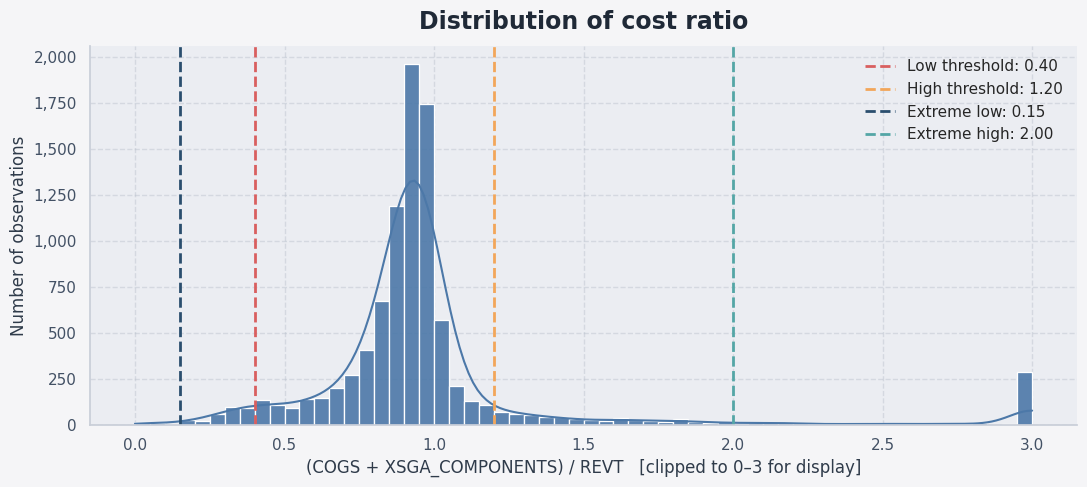

In [4]:
# ── Cost ratio distribution ──────────────────────────────────────────────────
plot_data = panel.loc[panel["cost_ratio"].notna(), "cost_ratio"]

fig, ax = plot_ratio_distribution(
    plot_data,
    low_threshold=LOW_THRESHOLD,
    high_threshold=HIGH_THRESHOLD,
    extreme_low=EXTREME_LOW_THRESHOLD,
    extreme_high=EXTREME_HIGH_THRESHOLD,
)
plt.show()
plt.close(fig)


In [5]:
# ── Overall summary ──────────────────────────────────────────────────────────
print("=== cost_ratio descriptive statistics ===")
print(panel[["cost_ratio"]].describe().to_string())

print("\nThresholds:")
print(f"  LOW_THRESHOLD          = {LOW_THRESHOLD}")
print(f"  HIGH_THRESHOLD         = {HIGH_THRESHOLD}")
print(f"  EXTREME_LOW_THRESHOLD  = {EXTREME_LOW_THRESHOLD}")
print(f"  EXTREME_HIGH_THRESHOLD = {EXTREME_HIGH_THRESHOLD}")
print(f"  MIN_REVENUE            = {MIN_REVENUE}")

n_total           = len(panel)
n_valid           = int(panel["REVT_valid"].sum())
n_flagged         = int(panel["flag_any"].sum())
n_low             = int(panel["flag_low"].sum())
n_high            = int(panel["flag_high"].sum())
n_extreme         = int(panel["flag_extreme_any"].sum())
n_extreme_low     = int(panel["flag_extreme_low"].sum())
n_extreme_high    = int(panel["flag_extreme_high"].sum())

n_firms_total     = panel["Ticker"].nunique()
n_firms_valid     = panel.loc[panel["REVT_valid"], "Ticker"].nunique()
n_firms_flagged   = panel.loc[panel["flag_any"], "Ticker"].nunique()
n_firms_extreme   = panel.loc[panel["flag_extreme_any"], "Ticker"].nunique()

print("\n=== Flag counts ===")
print(f"  Total rows             : {n_total:,}")
print(f"  Valid ratio rows       : {n_valid:,}")
print(f"  Flagged rows (any)     : {n_flagged:,}  ({n_flagged/n_valid:.1%} of valid)")
print(f"    Low flagged          : {n_low:,}  ({n_low/n_valid:.1%})")
print(f"    High flagged         : {n_high:,}  ({n_high/n_valid:.1%})")
print(f"  Extreme rows (any)     : {n_extreme:,}  ({n_extreme/n_valid:.1%})")
print(f"    Extreme low          : {n_extreme_low:,}")
print(f"    Extreme high         : {n_extreme_high:,}")

print("\n=== Unique companies ===")
print(f"  Total companies        : {n_firms_total:,}")
print(f"  Valid companies        : {n_firms_valid:,}")
print(f"  Flagged companies      : {n_firms_flagged:,}")
print(f"  Extreme companies      : {n_firms_extreme:,}")

# Summary table
flag_summary = pd.DataFrame({
    "Metric": [
        "Total rows", "Valid ratio rows",
        "Flagged rows (any)", "Low flagged", "High flagged",
        "Extreme rows (any)", "Extreme low", "Extreme high",
        "Total companies", "Valid companies",
        "Flagged companies", "Extreme companies",
    ],
    "Count": [
        n_total, n_valid,
        n_flagged, n_low, n_high,
        n_extreme, n_extreme_low, n_extreme_high,
        n_firms_total, n_firms_valid,
        n_firms_flagged, n_firms_extreme,
    ],
})
display_summary_table(flag_summary)


=== cost_ratio descriptive statistics ===
        cost_ratio
count  9367.000000
mean      1.350040
std       3.945204
min       0.000000
25%       0.839183
50%       0.925850
75%       0.984954
max     107.758662

Thresholds:
  LOW_THRESHOLD          = 0.4
  HIGH_THRESHOLD         = 1.2
  EXTREME_LOW_THRESHOLD  = 0.15
  EXTREME_HIGH_THRESHOLD = 2.0
  MIN_REVENUE            = 1.0

=== Flag counts ===
  Total rows             : 9,773
  Valid ratio rows       : 9,367
  Flagged rows (any)     : 1,269  (13.5% of valid)
    Low flagged          : 333  (3.6%)
    High flagged         : 936  (10.0%)
  Extreme rows (any)     : 443  (4.7%)
    Extreme low          : 32
    Extreme high         : 411

=== Unique companies ===
  Total companies        : 635
  Valid companies        : 627
  Flagged companies      : 243
  Extreme companies      : 101


Metric,Count
Total rows,9773
Valid ratio rows,9367
Flagged rows (any),1269
Low flagged,333
High flagged,936
Extreme rows (any),443
Extreme low,32
Extreme high,411
Total companies,635
Valid companies,627


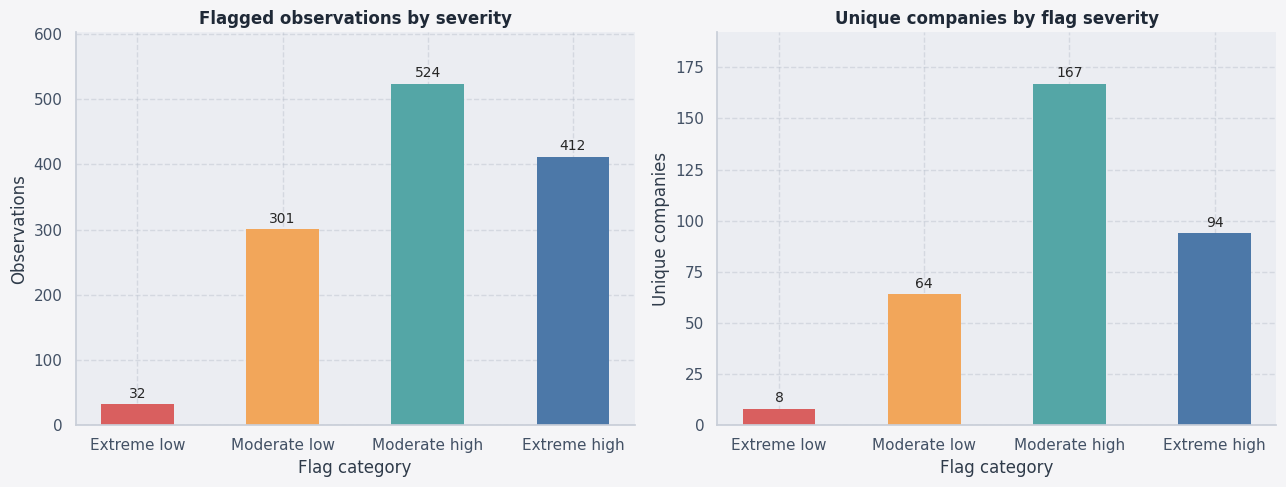

,flag_category,observations,unique_companies
0,Extreme low,32,8
1,Moderate low,301,64
2,Moderate high,524,167
3,Extreme high,412,94


In [6]:
# ── Flag severity breakdown ───────────────────────────────────────────────────
CATEGORIES     = ["Extreme low", "Moderate low", "Moderate high", "Extreme high"]
CATEGORY_COLORS = {
    "Extreme low":   PALETTE.get("red",    "#d62728"),
    "Moderate low":  PALETTE.get("orange", "#ff7f0e"),
    "Moderate high": PALETTE.get("teal",   "#17becf"),
    "Extreme high":  PALETTE.get("blue",   "#1f77b4"),
}

valid = panel.loc[panel["REVT_valid"] & panel["cost_ratio"].notna()].copy()
valid["flag_category"] = pd.cut(
    valid["cost_ratio"],
    bins=[-np.inf, EXTREME_LOW_THRESHOLD, LOW_THRESHOLD,
          HIGH_THRESHOLD, EXTREME_HIGH_THRESHOLD, np.inf],
    labels=["Extreme low", "Moderate low", "Normal", "Moderate high", "Extreme high"],
    right=False,
)
outside = valid.loc[valid["flag_category"].isin(CATEGORIES)].copy()

obs_counts  = outside["flag_category"].value_counts().reindex(CATEGORIES, fill_value=0)
firm_counts = (
    outside.groupby("flag_category", observed=True)["Ticker"]
    .nunique()
    .reindex(CATEGORIES, fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, counts, title, ylabel in [
    (axes[0], obs_counts,  "Flagged observations by severity",  "Observations"),
    (axes[1], firm_counts, "Unique companies by flag severity",  "Unique companies"),
]:
    bars = ax.bar(
        counts.index, counts.values,
        color=[CATEGORY_COLORS[c] for c in CATEGORIES],
        width=0.5, edgecolor="none",
    )
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(counts.values) * 0.01,
                f"{val:,}", ha="center", va="bottom", fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Flag category")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(counts.values) * 1.15)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()
plt.close(fig)

severity_table = pd.DataFrame({
    "flag_category":    CATEGORIES,
    "observations":     obs_counts.values,
    "unique_companies": firm_counts.values,
})
display(severity_table)


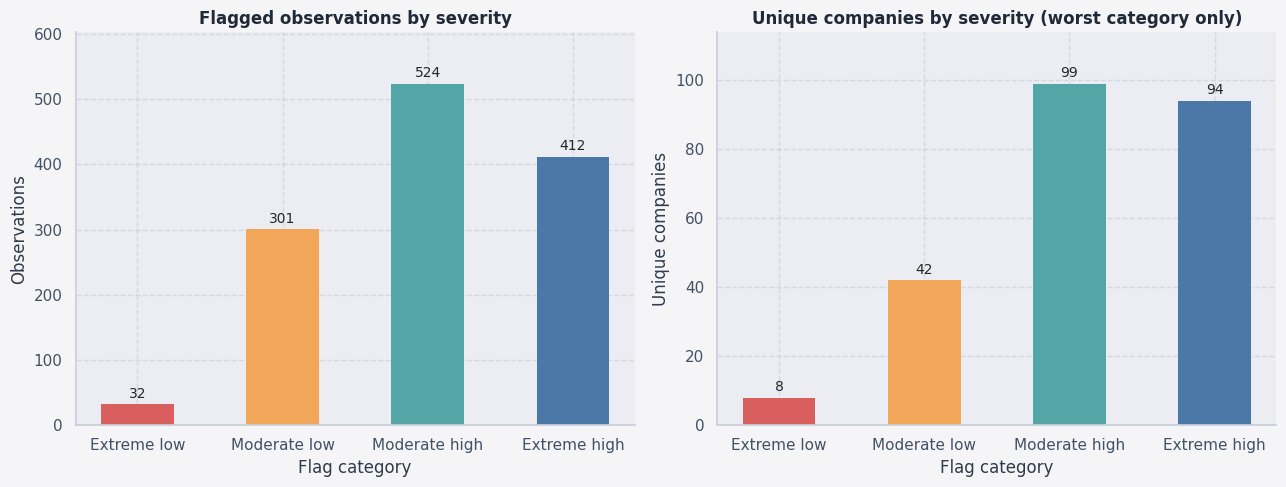

,flag_category,observations,unique_companies
0,Extreme low,32,8
1,Moderate low,301,42
2,Moderate high,524,99
3,Extreme high,412,94


In [15]:
# ── Flag severity breakdown – unique companies counted once (worst category) ──
CATEGORIES = ["Extreme low", "Moderate low", "Moderate high", "Extreme high"]
CATEGORY_COLORS = {
    "Extreme low":   PALETTE.get("red",    "#d62728"),
    "Moderate low":  PALETTE.get("orange", "#ff7f0e"),
    "Moderate high": PALETTE.get("teal",   "#17becf"),
    "Extreme high":  PALETTE.get("blue",   "#1f77b4"),
}

# Severity rank: higher = worse (extreme beats moderate)
SEVERITY_RANK = {
    "Extreme low":   3,
    "Extreme high":  3,
    "Moderate low":  1,
    "Moderate high": 1,
    "Normal":        0,
}

valid = panel.loc[panel["REVT_valid"] & panel["cost_ratio"].notna()].copy()
valid["flag_category"] = pd.cut(
    valid["cost_ratio"],
    bins=[-np.inf, EXTREME_LOW_THRESHOLD, LOW_THRESHOLD,
          HIGH_THRESHOLD, EXTREME_HIGH_THRESHOLD, np.inf],
    labels=["Extreme low", "Moderate low", "Normal", "Moderate high", "Extreme high"],
    right=False,
)
outside = valid.loc[valid["flag_category"].isin(CATEGORIES)].copy()

# Observation counts (unchanged – each row counts once in its own category)
obs_counts = outside["flag_category"].value_counts().reindex(CATEGORIES, fill_value=0)

# Unique companies: assign each ticker its single worst category
outside["severity_rank"] = outside["flag_category"].map(SEVERITY_RANK)
worst_per_firm = (
    outside.sort_values("severity_rank", ascending=False)
    .drop_duplicates(subset="Ticker", keep="first")
)
firm_counts = (
    worst_per_firm["flag_category"]
    .value_counts()
    .reindex(CATEGORIES, fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, counts, title, ylabel in [
    (axes[0], obs_counts,  "Flagged observations by severity",                 "Observations"),
    (axes[1], firm_counts, "Unique companies by severity (worst category only)", "Unique companies"),
]:
    bars = ax.bar(
        counts.index, counts.values,
        color=[CATEGORY_COLORS[c] for c in CATEGORIES],
        width=0.5, edgecolor="none",
    )
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(counts.values) * 0.01,
                f"{val:,}", ha="center", va="bottom", fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Flag category")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(counts.values) * 1.15)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()
plt.close(fig)

severity_table = pd.DataFrame({
    "flag_category":    CATEGORIES,
    "observations":     obs_counts.values,
    "unique_companies": firm_counts.values,
})
display(severity_table)

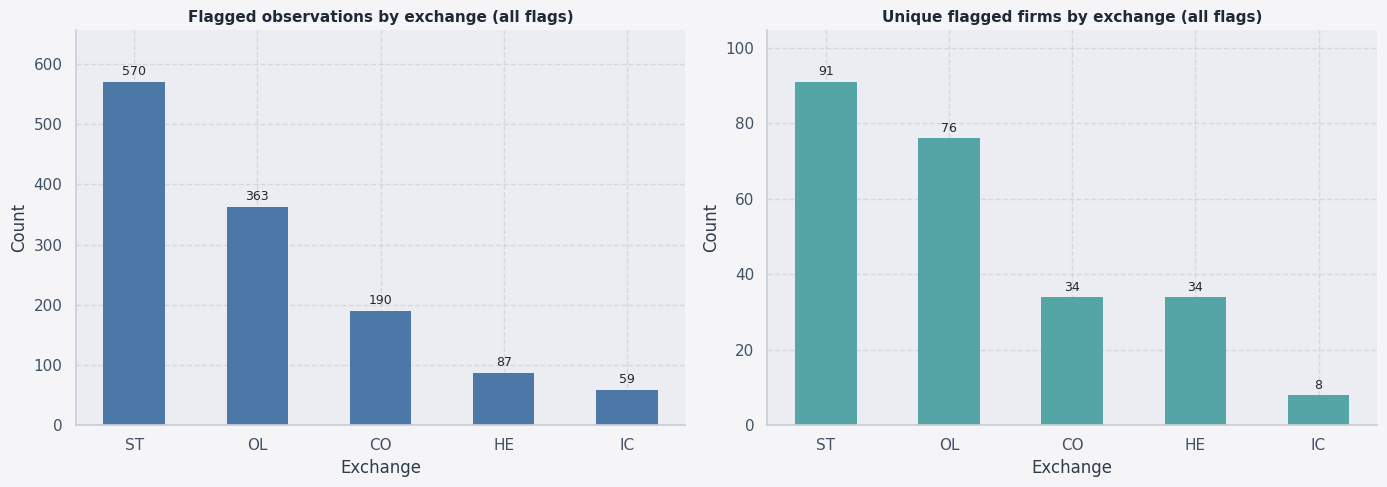

In [7]:
# ── Exchange breakdown – all flagged ─────────────────────────────────────────
flagged_all = panel.loc[panel["flag_any"]].copy()

exchange_obs   = flagged_all.groupby("Exchange").size().sort_values(ascending=False).head(TOP_N_EXCHANGES)
exchange_firms = (
    flagged_all.groupby("Exchange")["Ticker"].nunique()
    .sort_values(ascending=False).head(TOP_N_EXCHANGES)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, title, color in [
    (axes[0], exchange_obs,   "Flagged observations by exchange (all flags)",  PALETTE["blue"]),
    (axes[1], exchange_firms, "Unique flagged firms by exchange (all flags)",   PALETTE["teal"]),
]:
    bars = ax.bar(data.index, data.values, color=color, width=0.5, edgecolor="none")
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(data.values) * 0.01,
                f"{val:,}", ha="center", va="bottom", fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Exchange")
    ax.set_ylabel(ax.get_ylabel() or "Count")
    ax.set_ylim(0, max(data.values) * 1.15)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()
plt.close(fig)


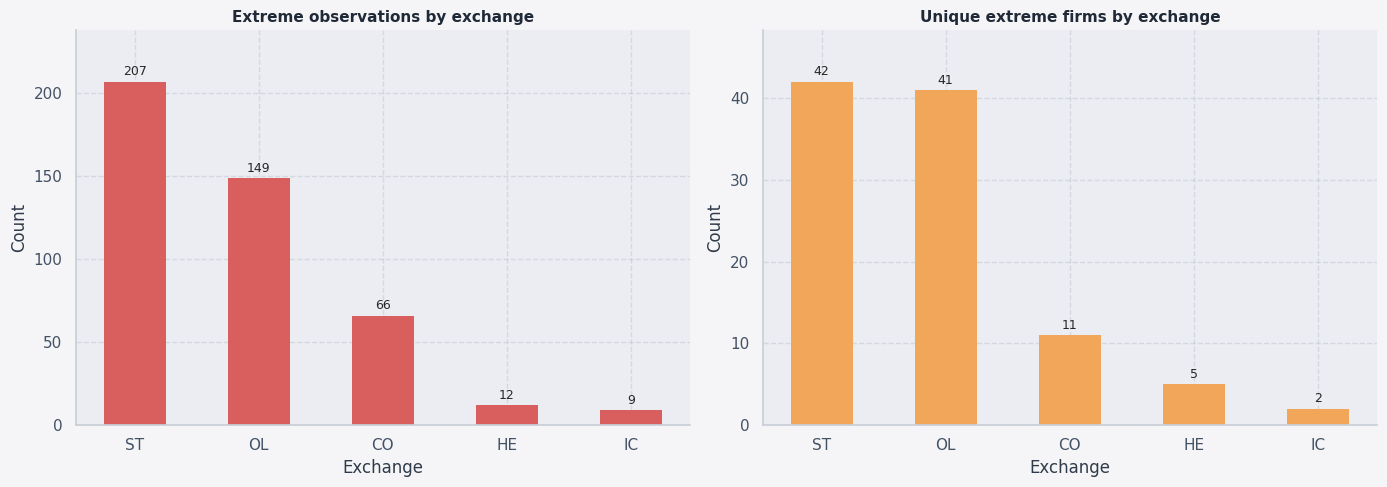

,Exchange,extreme_observations,unique_extreme_firms
0,ST,207,42
1,OL,149,41
2,CO,66,11
3,HE,12,5
4,IC,9,2


In [8]:
# ── Exchange breakdown – extreme only ────────────────────────────────────────
flagged_extreme = panel.loc[panel["flag_extreme_any"]].copy()

extr_exch_obs   = flagged_extreme.groupby("Exchange").size().sort_values(ascending=False).head(TOP_N_EXCHANGES)
extr_exch_firms = (
    flagged_extreme.groupby("Exchange")["Ticker"].nunique()
    .sort_values(ascending=False).head(TOP_N_EXCHANGES)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, title, color in [
    (axes[0], extr_exch_obs,   "Extreme observations by exchange",  PALETTE.get("red", "#d62728")),
    (axes[1], extr_exch_firms, "Unique extreme firms by exchange",   PALETTE.get("orange", "#ff7f0e")),
]:
    bars = ax.bar(data.index, data.values, color=color, width=0.5, edgecolor="none")
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(data.values) * 0.01,
                f"{val:,}", ha="center", va="bottom", fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Exchange")
    ax.set_ylabel("Count")
    ax.set_ylim(0, max(data.values) * 1.15)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()
plt.close(fig)

# Exchange summary table – extreme
extr_exch_table = pd.DataFrame({
    "Exchange": extr_exch_obs.index,
    "extreme_observations": extr_exch_obs.values,
    "unique_extreme_firms": extr_exch_firms.reindex(extr_exch_obs.index).fillna(0).astype(int).values,
})
display(extr_exch_table)


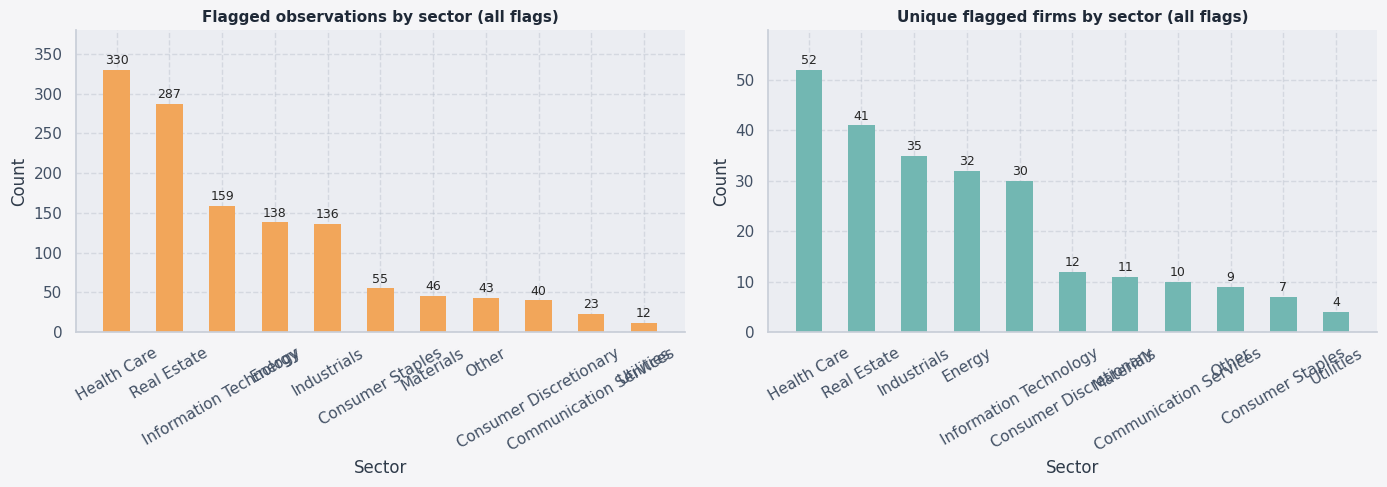

In [9]:
# ── Sector breakdown – all flagged ──────────────────────────────────────────
if "Sector" in panel.columns:
    sector_obs   = flagged_all.groupby("Sector").size().sort_values(ascending=False).head(TOP_N_SECTORS)
    sector_firms = (
        flagged_all.groupby("Sector")["Ticker"].nunique()
        .sort_values(ascending=False).head(TOP_N_SECTORS)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, data, title, color in [
        (axes[0], sector_obs,   "Flagged observations by sector (all flags)",  PALETTE["orange"]),
        (axes[1], sector_firms, "Unique flagged firms by sector (all flags)",   PALETTE["green"]),
    ]:
        bars = ax.bar(data.index, data.values, color=color, width=0.5, edgecolor="none")
        for bar, val in zip(bars, data.values):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(data.values) * 0.01,
                    f"{val:,}", ha="center", va="bottom", fontsize=9)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Sector")
        ax.set_ylabel("Count")
        ax.set_ylim(0, max(data.values) * 1.15)
        ax.tick_params(axis="x", rotation=30)
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()
    plt.close(fig)
else:
    print("Column 'Sector' not found.")


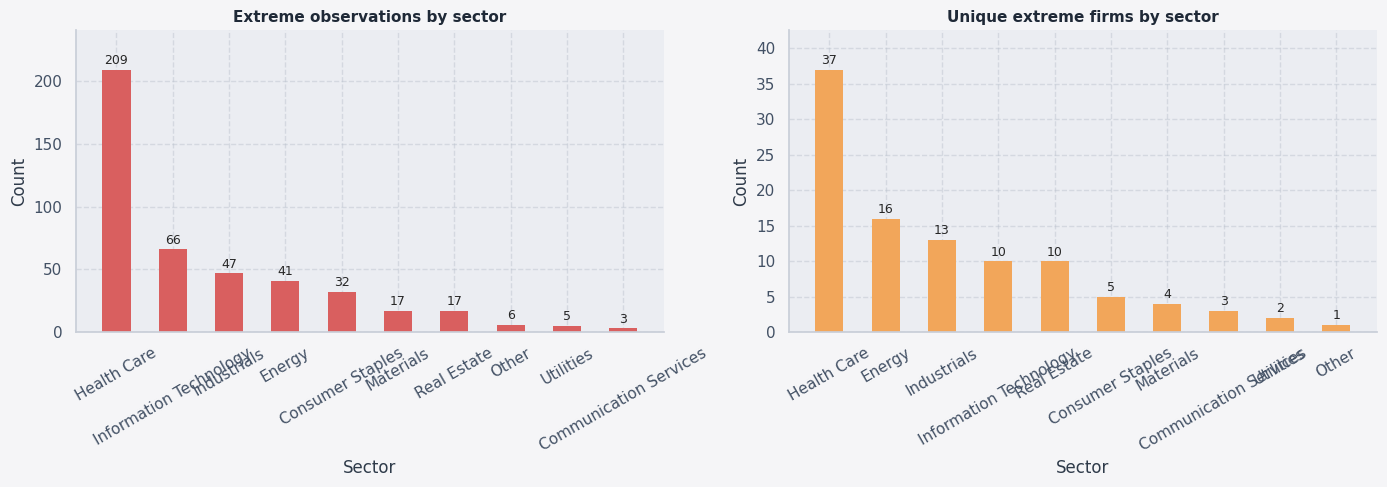

,Sector,extreme_observations,unique_extreme_firms
0,Health Care,209,37
1,Information Technology,66,10
2,Industrials,47,13
3,Energy,41,16
4,Consumer Staples,32,5
5,Materials,17,4
6,Real Estate,17,10
7,Other,6,1
8,Utilities,5,2
9,Communication Services,3,3


In [10]:
# ── Sector breakdown – extreme only ─────────────────────────────────────────
if "Sector" in panel.columns:
    extr_sect_obs   = flagged_extreme.groupby("Sector").size().sort_values(ascending=False).head(TOP_N_SECTORS)
    extr_sect_firms = (
        flagged_extreme.groupby("Sector")["Ticker"].nunique()
        .sort_values(ascending=False).head(TOP_N_SECTORS)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, data, title, color in [
        (axes[0], extr_sect_obs,   "Extreme observations by sector",  PALETTE.get("red", "#d62728")),
        (axes[1], extr_sect_firms, "Unique extreme firms by sector",   PALETTE.get("orange", "#ff7f0e")),
    ]:
        bars = ax.bar(data.index, data.values, color=color, width=0.5, edgecolor="none")
        for bar, val in zip(bars, data.values):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(data.values) * 0.01,
                    f"{val:,}", ha="center", va="bottom", fontsize=9)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Sector")
        ax.set_ylabel("Count")
        ax.set_ylim(0, max(data.values) * 1.15)
        ax.tick_params(axis="x", rotation=30)
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

    # Sector summary table – extreme
    extr_sect_table = pd.DataFrame({
        "Sector": extr_sect_obs.index,
        "extreme_observations": extr_sect_obs.values,
        "unique_extreme_firms": extr_sect_firms.reindex(extr_sect_obs.index).fillna(0).astype(int).values,
    })
    display(extr_sect_table)
else:
    print("Column 'Sector' not found.")


In [11]:
# ── Build extreme review tables ───────────────────────────────────────────────
# Classify flag type
extreme = panel.loc[panel["flag_extreme_any"]].copy()

extreme["flag_type"] = np.select(
    [
        extreme["flag_extreme_low"] & extreme["flag_extreme_high"],
        extreme["flag_extreme_low"],
        extreme["flag_extreme_high"],
    ],
    ["Both", "Extreme Low", "Extreme High"],
    default="Not flagged",
)

print(f"Extreme rows: {len(extreme):,}")
print(f"Unique extreme firms: {extreme['Ticker'].nunique():,}")

# ── Sort: alphabetically by exchange suffix, then by Ticker ──────────────────
EXCHANGE_ORDER = ["CO", "HE", "IC", "OL", "ST"]   # alphabetical

extreme["exchange_suffix"] = (
    extreme["Ticker"].str.split(".").str[-1].str.upper().fillna("ZZ")
)
order_map = {s: i for i, s in enumerate(EXCHANGE_ORDER)}
extreme["exchange_order"] = (
    extreme["exchange_suffix"].map(order_map).fillna(len(EXCHANGE_ORDER)).astype(int)
)

show_cols = [
    "Ticker", "CompanyName", "Year", "Exchange", "Industry", "Sector",
    "REVT", "COGS", "XSGA_COMPONENTS", "TOTAL_COST_PROXY",
    "cost_ratio", "flag_type",
]
show_cols = [c for c in show_cols if c in extreme.columns]

# ── Split into low / high for separate review ─────────────────────────────────
extreme_sorted = (
    extreme
    .sort_values(["exchange_order", "Ticker", "Year"], ascending=[True, True, True])
    .reset_index(drop=True)
)

extreme_low_table  = extreme_sorted.loc[extreme_sorted["flag_type"] == "Extreme Low",  show_cols].reset_index(drop=True)
extreme_high_table = extreme_sorted.loc[extreme_sorted["flag_type"] == "Extreme High", show_cols].reset_index(drop=True)

print(f"\nExtreme LOW  rows: {len(extreme_low_table):,}  |  unique firms: {extreme_low_table['Ticker'].nunique():,}")
print(f"Extreme HIGH rows: {len(extreme_high_table):,}  |  unique firms: {extreme_high_table['Ticker'].nunique():,}")


Extreme rows: 443
Unique extreme firms: 101

Extreme LOW  rows: 32  |  unique firms: 8
Extreme HIGH rows: 411  |  unique firms: 93


In [12]:
# ── Extreme values statistics ─────────────────────────────────────────────────
print("=== Extreme LOW values (cost_ratio < {}) ===".format(EXTREME_LOW_THRESHOLD))
if len(extreme_low_table):
    print(f"  Rows             : {len(extreme_low_table):,}")
    print(f"  Unique companies : {extreme_low_table['Ticker'].nunique():,}")
    if "Exchange" in extreme_low_table.columns:
        print(f"  Exchanges        : {extreme_low_table['Exchange'].nunique():,}")
        print("  By exchange:")
        for exch, grp in extreme_low_table.groupby("Exchange"):
            print(f"    {exch:8s}  {grp['Ticker'].nunique():3d} firms  |  {len(grp):4d} rows")
    if "Sector" in extreme_low_table.columns:
        print(f"  Sectors          : {extreme_low_table['Sector'].nunique():,}")
        print("  By sector (top 10):")
        for sect, grp in extreme_low_table.groupby("Sector"):
            print(f"    {sect:35s}  {grp['Ticker'].nunique():3d} firms  |  {len(grp):4d} rows")

print()
print("=== Extreme HIGH values (cost_ratio > {}) ===".format(EXTREME_HIGH_THRESHOLD))
if len(extreme_high_table):
    print(f"  Rows             : {len(extreme_high_table):,}")
    print(f"  Unique companies : {extreme_high_table['Ticker'].nunique():,}")
    if "Exchange" in extreme_high_table.columns:
        print(f"  Exchanges        : {extreme_high_table['Exchange'].nunique():,}")
        print("  By exchange:")
        for exch, grp in extreme_high_table.groupby("Exchange"):
            print(f"    {exch:8s}  {grp['Ticker'].nunique():3d} firms  |  {len(grp):4d} rows")
    if "Sector" in extreme_high_table.columns:
        print(f"  Sectors          : {extreme_high_table['Sector'].nunique():,}")
        print("  By sector:")
        for sect, grp in extreme_high_table.groupby("Sector"):
            print(f"    {sect:35s}  {grp['Ticker'].nunique():3d} firms  |  {len(grp):4d} rows")


=== Extreme LOW values (cost_ratio < 0.15) ===
  Rows             : 32
  Unique companies : 8
  Exchanges        : 4
  By exchange:
    CO          4 firms  |    24 rows
    HE          1 firms  |     3 rows
    OL          1 firms  |     3 rows
    ST          2 firms  |     2 rows
  Sectors          : 4
  By sector (top 10):
    Consumer Staples                       2 firms  |    11 rows
    Industrials                            2 firms  |    15 rows
    Materials                              1 firms  |     1 rows
    Real Estate                            3 firms  |     5 rows

=== Extreme HIGH values (cost_ratio > 2.0) ===
  Rows             : 411
  Unique companies : 93
  Exchanges        : 5
  By exchange:
    CO          7 firms  |    42 rows
    HE          4 firms  |     9 rows
    IC          2 firms  |     9 rows
    OL         40 firms  |   146 rows
    ST         40 firms  |   205 rows
  Sectors          : 10
  By sector:
    Communication Services                 3 firm

In [13]:
# ── Extreme LOW – scrollable review table ────────────────────────────────────
print(f"Extreme LOW  (cost_ratio < {EXTREME_LOW_THRESHOLD}) — sorted alphabetically by exchange, then ticker")
print(f"Rows: {len(extreme_low_table):,}  |  Unique firms: {extreme_low_table['Ticker'].nunique():,}")

display(
    HTML(
        "<div style='max-height:600px; overflow-y:auto'>"
        + extreme_low_table.to_html(index=False, max_rows=None, max_cols=None)
        + "</div>"
    )
)


Extreme LOW  (cost_ratio < 0.15) — sorted alphabetically by exchange, then ticker
Rows: 32  |  Unique firms: 8


Ticker,CompanyName,Year,Exchange,Industry,Sector,REVT,COGS,XSGA_COMPONENTS,TOTAL_COST_PROXY,cost_ratio,flag_type
ENSG.CO,Ennogie Solar Group A/S,2005,CO,Construction & Engineering,Industrials,195.29,0.00,0.00,0.00,0.000000,Extreme Low
ENSG.CO,Ennogie Solar Group A/S,2006,CO,Construction & Engineering,Industrials,240.04,0.00,3.84,3.84,0.015997,Extreme Low
ENSG.CO,Ennogie Solar Group A/S,2008,CO,Construction & Engineering,Industrials,271.63,0.00,2.94,2.94,0.010824,Extreme Low
ENSG.CO,Ennogie Solar Group A/S,2009,CO,Construction & Engineering,Industrials,177.39,0.00,0.00,0.00,0.000000,Extreme Low
ENSG.CO,Ennogie Solar Group A/S,2010,CO,Construction & Engineering,Industrials,36.32,0.00,0.00,0.00,0.000000,Extreme Low
ENSG.CO,Ennogie Solar Group A/S,2011,CO,Construction & Engineering,Industrials,88.94,0.00,0.00,0.00,0.000000,Extreme Low
ENSG.CO,Ennogie Solar Group A/S,2012,CO,Construction & Engineering,Industrials,40.23,0.00,0.00,0.00,0.000000,Extreme Low
ENSG.CO,Ennogie Solar Group A/S,2013,CO,Construction & Engineering,Industrials,78.28,0.00,7.84,7.84,0.100153,Extreme Low
ENSG.CO,Ennogie Solar Group A/S,2014,CO,Construction & Engineering,Industrials,37.04,0.00,3.38,3.38,0.091253,Extreme Low
ENSG.CO,Ennogie Solar Group A/S,2015,CO,Construction & Engineering,Industrials,150.72,0.00,4.17,4.17,0.027667,Extreme Low


In [14]:
# ── Extreme HIGH – scrollable review table ────────────────────────────────────
print(f"Extreme HIGH (cost_ratio > {EXTREME_HIGH_THRESHOLD}) — sorted alphabetically by exchange, then ticker")
print(f"Rows: {len(extreme_high_table):,}  |  Unique firms: {extreme_high_table['Ticker'].nunique():,}")

display(
    HTML(
        "<div style='max-height:600px; overflow-y:auto'>"
        + extreme_high_table.to_html(index=False, max_rows=None, max_cols=None)
        + "</div>"
    )
)


Extreme HIGH (cost_ratio > 2.0) — sorted alphabetically by exchange, then ticker
Rows: 411  |  Unique firms: 93


Ticker,CompanyName,Year,Exchange,Industry,Sector,REVT,COGS,XSGA_COMPONENTS,TOTAL_COST_PROXY,cost_ratio,flag_type
ATLA.CO,Atlantic Petroleum P/F,2014,CO,Oil & Gas,Energy,384.75,594.27,320.36,914.63,2.377206,Extreme High
ATLA.CO,Atlantic Petroleum P/F,2015,CO,Oil & Gas,Energy,223.95,728.58,472.74,1201.32,5.364233,Extreme High
ATLA.CO,Atlantic Petroleum P/F,2016,CO,Oil & Gas,Energy,12.76,64.33,126.70,191.03,14.971003,Extreme High
BAVA.CO,Bavarian Nordic A/S,2006,CO,Pharmaceuticals,Health Care,189.12,147.04,261.94,408.98,2.162542,Extreme High
BAVA.CO,Bavarian Nordic A/S,2008,CO,Pharmaceuticals,Health Care,230.71,217.34,244.85,462.19,2.003338,Extreme High
BAVA.CO,Bavarian Nordic A/S,2009,CO,Pharmaceuticals,Health Care,87.68,164.26,323.45,487.71,5.562386,Extreme High
BAVA.CO,Bavarian Nordic A/S,2010,CO,Pharmaceuticals,Health Care,337.65,477.84,369.49,847.33,2.509492,Extreme High
BIOPOR.CO,Bioporto A/S,2005,CO,Healthcare Equipment & Supplies,Health Care,4.69,4.82,15.29,20.11,4.287846,Extreme High
BIOPOR.CO,Bioporto A/S,2006,CO,Healthcare Equipment & Supplies,Health Care,5.99,2.61,19.20,21.81,3.641068,Extreme High
BIOPOR.CO,Bioporto A/S,2007,CO,Healthcare Equipment & Supplies,Health Care,8.97,4.97,19.10,24.07,2.683389,Extreme High


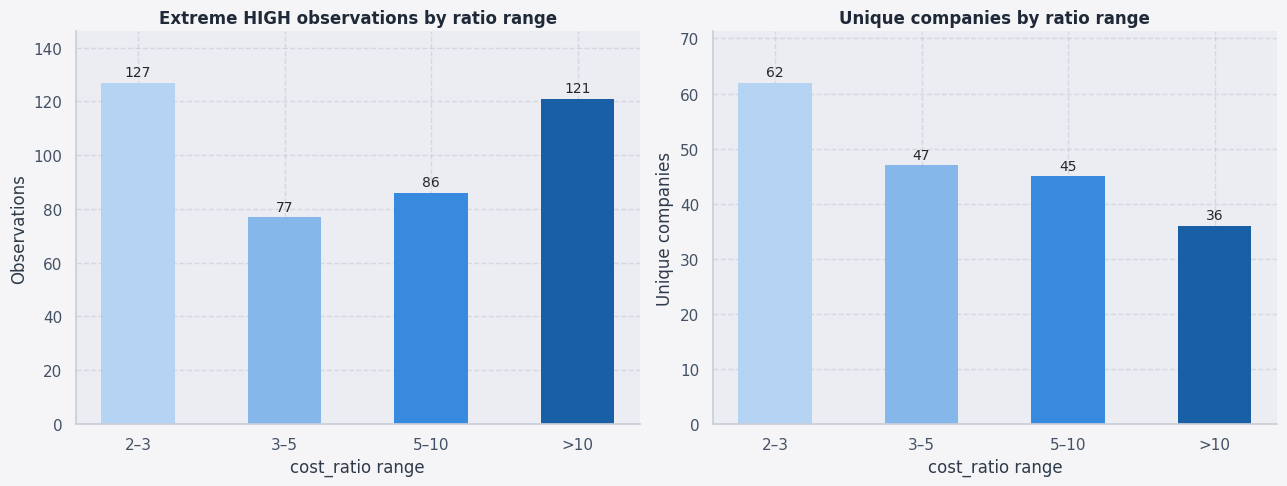

=== Companies per ratio bucket × revenue size (REVT) ===


revt_bucket,<10,10–100,100–500,>500
ratio_bucket,,,,
2–3,1,12,6,1
3–5,4,9,3,0
5–10,5,11,4,1
>10,30,6,0,0



=== Extreme HIGH by exchange ===


,observations,unique_firms,median_ratio,max_ratio
Exchange,,,,
OL,146,40,4.682272,100.308219
ST,205,40,6.038431,92.291667
CO,42,7,3.520988,30.455733
HE,9,4,4.085207,40.548951
IC,9,2,13.429146,107.758662



=== Extreme HIGH by sector ===


,observations,unique_firms,median_ratio,max_ratio
Sector,,,,
Health Care,209,37,6.134981,107.758662
Energy,41,16,3.363636,53.391304
Industrials,32,11,3.326320,36.029197
Information Technology,66,10,5.861216,100.308219
Real Estate,12,7,3.027804,8.198529
Communication Services,3,3,2.097902,18.015625
Consumer Staples,21,3,4.006070,21.601695
Materials,16,3,6.663924,42.826389
Utilities,5,2,2.806259,9.143251



=== Top 30 companies by worst single-year cost_ratio ===


Ticker,CompanyName,Exchange,Sector,n_extreme_years,REVT,cost_ratio,ratio_bucket,revt_bucket
OCS.IC,Oculis Holding AG,IC,Health Care,5,8.37,107.758662,>10,<10
ENSU.OL,Ensurge Micropower ASA,OL,Information Technology,14,1.46,100.308219,>10,<10
QLINEA.ST,Q linea AB,ST,Health Care,5,2.40,92.291667,>10,<10
IDEX.OL,Idex Biometrics ASA,OL,Information Technology,15,1.51,86.013245,>10,<10
ONCIN.OL,Oncoinvent ASA,OL,Health Care,2,2.34,84.132479,>10,<10
IMMUN.ST,Mendus AB (publ),ST,Health Care,1,1.70,75.970588,>10,<10
PLT.OL,Polight ASA,OL,Information Technology,7,1.04,75.163462,>10,<10
CRNA.OL,Circio Holding ASA,OL,Health Care,2,2.25,67.791111,>10,<10
VIVE.ST,Vivesto AB,ST,Health Care,7,1.84,66.201087,>10,<10
MGN.OL,Magnora ASA,OL,Energy,7,2.30,53.391304,>10,<10


In [17]:
# ── Extreme HIGH deep-dive ────────────────────────────────────────────────────
# Requires: extreme_high_table (built in the cell above)

# ── 1. Bucket by ratio range ─────────────────────────────────────────────────
RATIO_BINS   = [2, 3, 5, 10, np.inf]
RATIO_LABELS = ["2–3", "3–5", "5–10", ">10"]

eht = extreme_high_table.copy()
eht["ratio_bucket"] = pd.cut(
    eht["cost_ratio"],
    bins=RATIO_BINS,
    labels=RATIO_LABELS,
    right=False,
)

bucket_obs   = eht["ratio_bucket"].value_counts().reindex(RATIO_LABELS, fill_value=0)
bucket_firms = (
    eht.groupby("ratio_bucket", observed=True)["Ticker"]
    .nunique()
    .reindex(RATIO_LABELS, fill_value=0)
)

# ── 2. Worst ratio per company ────────────────────────────────────────────────
worst = (
    eht.sort_values("cost_ratio", ascending=False)
    .drop_duplicates(subset="Ticker", keep="first")
    .sort_values("cost_ratio", ascending=False)
    .reset_index(drop=True)
)

# ── 3. How many years is each company extreme high? ───────────────────────────
years_extreme = (
    eht.groupby("Ticker")["Year"]
    .count()
    .rename("n_extreme_years")
    .reset_index()
)
worst = worst.merge(years_extreme, on="Ticker", how="left")

# ── 4. Revenue size buckets (to spot tiny-revenue outliers) ──────────────────
worst["revt_bucket"] = pd.cut(
    worst["REVT"],
    bins=[0, 10, 100, 500, np.inf],
    labels=["<10", "10–100", "100–500", ">500"],
    right=False,
)

# ── 5. Plot: ratio bucket distribution ───────────────────────────────────────
BUCKET_COLORS = ["#B5D4F4", "#85B7EB", "#378ADD", "#185FA5"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, counts, title, ylabel in [
    (axes[0], bucket_obs,   "Extreme HIGH observations by ratio range",  "Observations"),
    (axes[1], bucket_firms, "Unique companies by ratio range",            "Unique companies"),
]:
    bars = ax.bar(counts.index, counts.values,
                  color=BUCKET_COLORS, width=0.5, edgecolor="none")
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(counts.values) * 0.01,
                f"{val:,}", ha="center", va="bottom", fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("cost_ratio range")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(counts.values) * 1.15)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()
plt.close(fig)

# ── 6. Summary table: ratio bucket × revenue size ────────────────────────────
print("=== Companies per ratio bucket × revenue size (REVT) ===")
if "revt_bucket" in worst.columns:
    cross = pd.crosstab(worst["ratio_bucket"], worst["revt_bucket"])
    display(cross)

# ── 7. Per-exchange breakdown for extreme high ────────────────────────────────
print("\n=== Extreme HIGH by exchange ===")
exch_summary = (
    eht.groupby("Exchange")
    .agg(
        observations=("Ticker", "count"),
        unique_firms=("Ticker", "nunique"),
        median_ratio=("cost_ratio", "median"),
        max_ratio=("cost_ratio", "max"),
    )
    .sort_values("unique_firms", ascending=False)
)
display(exch_summary)

# ── 8. Per-sector breakdown ───────────────────────────────────────────────────
if "Sector" in eht.columns:
    print("\n=== Extreme HIGH by sector ===")
    sect_summary = (
        eht.groupby("Sector")
        .agg(
            observations=("Ticker", "count"),
            unique_firms=("Ticker", "nunique"),
            median_ratio=("cost_ratio", "median"),
            max_ratio=("cost_ratio", "max"),
        )
        .sort_values("unique_firms", ascending=False)
    )
    display(sect_summary)

# ── 9. Top 30 worst offenders (scrollable) ────────────────────────────────────
show_cols = [c for c in [
    "Ticker", "CompanyName", "Exchange", "Sector",
    "n_extreme_years", "REVT", "cost_ratio", "ratio_bucket", "revt_bucket",
] if c in worst.columns]

print(f"\n=== Top 30 companies by worst single-year cost_ratio ===")
display(
    HTML(
        "<div style='max-height:500px; overflow-y:auto'>"
        + worst[show_cols].head(30).to_html(index=False)
        + "</div>"
    )
)